# 这是初始第一阶段notebook

## 载入数据

In [8]:
# 1.导入库
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

In [9]:
# 2. Local data paths
DATA_ROOT = Path(r"D:\.kaggle\home-credit-credit-risk-model-stability")
TRAIN_DIR = DATA_ROOT / "parquet_files" / "train"
TEST_DIR = DATA_ROOT / "parquet_files" / "test"

In [10]:
# 3. 简要观看表和排序
train_files = sorted(TRAIN_DIR.glob("*.parquet"))
test_files = sorted(TEST_DIR.glob("*.parquet"))

print(f"Train parquet files: {len(train_files)}")
print(f"Test parquet files:  {len(test_files)}")


Train parquet files: 32
Test parquet files:  36


公开的test_base确实只有10*4，也没有target

In [11]:
# 4. Load base tables
train_base = pl.read_parquet(TRAIN_DIR / "train_base.parquet")
test_base = pl.read_parquet(TEST_DIR / "test_base.parquet")

print("train_base:", train_base.shape)
print("test_base: ", test_base.shape)

train_base: (1526659, 5)
test_base:  (10, 4)


In [12]:
# 5. 检查train_base
print(train_base.schema)
train_base.head(3)
base_summary = train_base.select(
    pl.col("target").mean().alias("default_rate"),
    pl.col("WEEK_NUM").min().alias("week_min"),
    pl.col("WEEK_NUM").max().alias("week_max"),
)
base_summary

Schema({'case_id': Int64, 'date_decision': String, 'MONTH': Int64, 'WEEK_NUM': Int64, 'target': Int64})


default_rate,week_min,week_max
f64,i64,i64
0.031437,0,91


In [13]:
# 6. 按周检查样本量和违约率
weekly_summary = (
    train_base
    .group_by("WEEK_NUM")
    .agg(
        pl.len().alias("n_cases"),
        pl.col("target").mean().alias("default_rate"),
    )
    .sort("WEEK_NUM")
)
print(f"Number of weeks: {weekly_summary.height}")
weekly_summary.head(20)

Number of weeks: 92


WEEK_NUM,n_cases,default_rate
i64,u32,f64
0,16735,0.023902
1,18841,0.025052
2,17476,0.026608
3,16108,0.026012
4,14309,0.028234
…,…,…
15,17713,0.028341
16,16598,0.032233
17,12146,0.036226


In [14]:
# 6.1 汇总全部周的样本量与违约率范围
weekly_summary.select(
    pl.col("n_cases").min().alias("min_weekly_cases"),
    pl.col("n_cases").max().alias("max_weekly_cases"),
    pl.col("default_rate").min().alias("min_default_rate"),
    pl.col("default_rate").max().alias("max_default_rate"),
)

min_weekly_cases,max_weekly_cases,min_default_rate,max_default_rate
u32,u32,f64,f64
825,35920,0.017722,0.052144


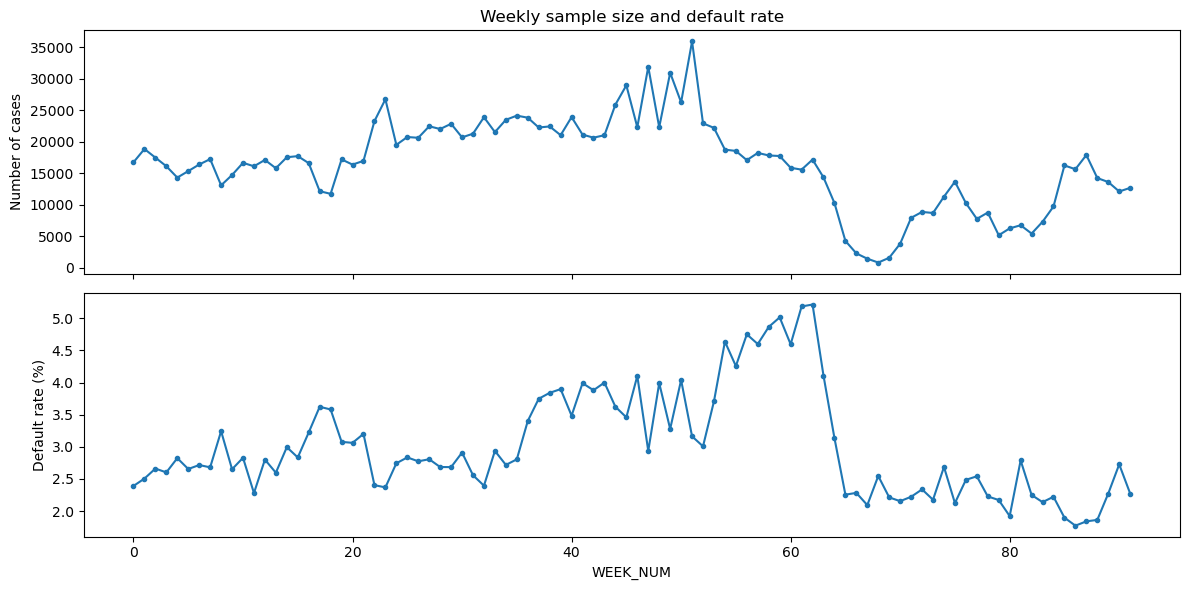

In [15]:
# 6.2 可视化每周样本量和违约率
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(
    weekly_summary["WEEK_NUM"],
    weekly_summary["n_cases"],
    marker="o",
    markersize=3,
)
axes[0].set_ylabel("Number of cases")
axes[0].set_title("Weekly sample size and default rate")

axes[1].plot(
    weekly_summary["WEEK_NUM"],
    weekly_summary["default_rate"] * 100,
    marker="o",
    markersize=3,
)
axes[1].set_xlabel("WEEK_NUM")
axes[1].set_ylabel("Default rate (%)")
plt.tight_layout()
plt.show()